In [1]:
!pip install tensorflow==2.16.2 matplotlib==3.9.1 "numpy<2.0"
!pip install jax==0.4.29 jaxlib==0.4.29 ml_dtypes --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 75.8 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-text 2.20.1 requires tensorfl

In [1]:
import os
# Suppress oneDNN optimizations and lower TensorFlow logging level
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load the data set
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the pixel values
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Expand dimensions to match the input shape (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Add noise to the data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip the values to be within the range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Define the diffusion model architecture with reduced complexity
input_layer = Input(shape=(28, 28, 1))
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_layer)  # Reduced filters
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)  # Reduced filters
x = Flatten()(x)
x = Dense(64, activation='relu')(x)  # Reduced size
x = Dense(28*28*32, activation='relu')(x)  # Reduced size
x = Reshape((28, 28, 32))(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)  # Reduced filters
x = Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)  # Reduced filters
output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
diffusion_model = Model(input_layer, output_layer)

# Compile the model with mixed precision and a different loss function
diffusion_model.compile(optimizer='adam', loss='mean_squared_error')  # Using MSE for regression tasks

# Summary of the optimized model
diffusion_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25088)          │     1,630,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,255,233 (12.42 MB)

 Trainable params: 3,255,233 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Cache and prefetch the data using TensorFlow data pipelines for faster loading
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_noisy, x_train))
train_dataset = train_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # Reduced batch size

val_dataset = tf.data.Dataset.from_tensor_slices((x_test_noisy, x_test))
val_dataset = val_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)  # Reduced batch size


In [5]:
# Implement early stopping based on validation loss
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the model with early stopping and smaller batch size
diffusion_model.fit(
    train_dataset,
    epochs=3,
    shuffle=True,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 312s 330ms/step - loss: 0.0337 - val_loss: 0.0155
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 307s 327ms/step - loss: 0.0127 - val_loss: 0.0130
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 310s 330ms/step - loss: 0.0111 - val_loss: 0.0124


313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step


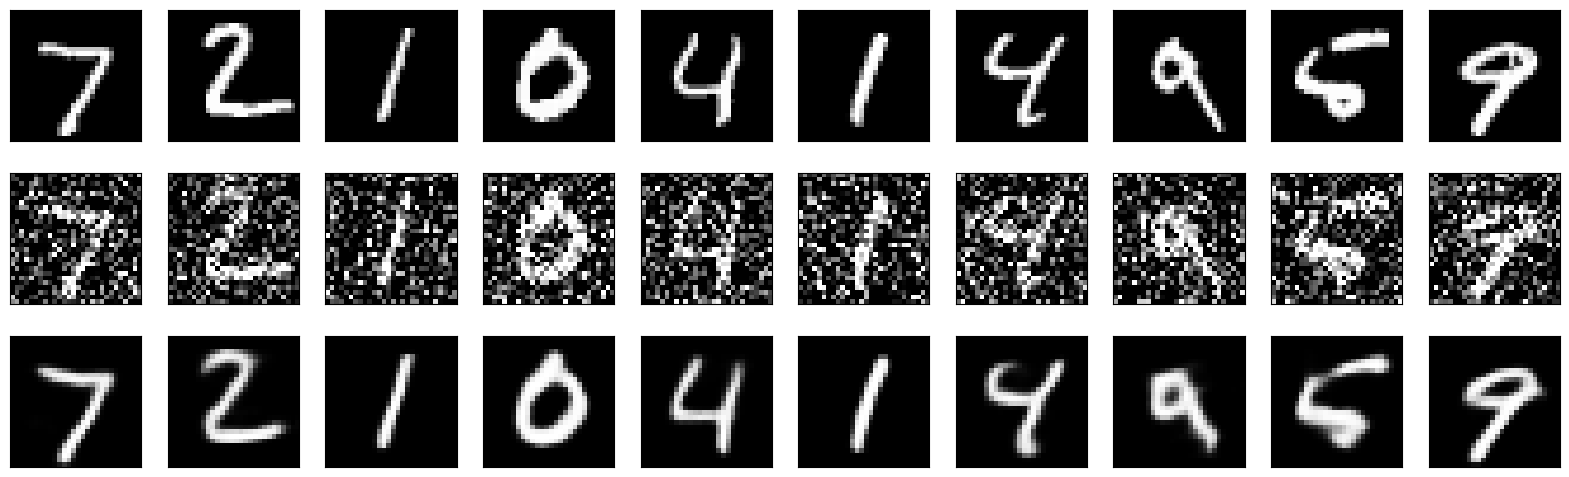

In [6]:
import matplotlib.pyplot as plt

# Predict the denoised images
denoised_images = diffusion_model.predict(x_test_noisy)

# Visualize the results
n = 10  # Number of digits to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [7]:
# Freeze all the layers
for layer in diffusion_model.layers:
    layer.trainable = False

In [8]:
# Check trainable status of each layer
for i, layer in enumerate(diffusion_model.layers):
    print(f"Layer {i}: {layer.name} — Trainable: {layer.trainable}")

Layer 0: input_layer — Trainable: False
Layer 1: conv2d — Trainable: False
Layer 2: conv2d_1 — Trainable: False
Layer 3: flatten — Trainable: False
Layer 4: dense — Trainable: False
Layer 5: dense_1 — Trainable: False
Layer 6: reshape — Trainable: False
Layer 7: conv2d_transpose — Trainable: False
Layer 8: conv2d_transpose_1 — Trainable: False
Layer 9: conv2d_2 — Trainable: False


In [9]:
# Unfreeze the top layers of the model
for layer in diffusion_model.layers[-4:]:
    layer.trainable = True

# Compile the model again
diffusion_model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model again
diffusion_model.fit(x_train_noisy, x_train,
                    epochs=10,
                    batch_size=64,
                    shuffle=True,
                    validation_data=(x_test_noisy, x_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 187s 197ms/step - loss: 0.0924 - val_loss: 0.0956
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 184s 196ms/step - loss: 0.0917 - val_loss: 0.0951
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 194s 206ms/step - loss: 0.0914 - val_loss: 0.0950
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 194s 198ms/step - loss: 0.0913 - val_loss: 0.0949
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 187s 199ms/step - loss: 0.0912 - val_loss: 0.0949
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 184s 196ms/step - loss: 0.0911 - val_loss: 0.0947
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 204s 198ms/step - loss: 0.0910 - val_loss: 0.0950
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 202s 198ms/step - loss: 0.0910 - val_loss: 0.0947
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 185s 197ms/step - loss: 0.0909 - val_loss: 0.0946
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 202s 197ms/step - loss: 0.0908 - val_loss: 0.0946


### Modify the noise factor

#### Objective:
- Change the noise factor and see how it affects the model’s ability to denoise images.
#### Instructions:
1. Change the noise factor to 0.3.
2. Add noise to the training and test data sets with the new noise factor.
3. Retrain the model with the new noisy data.

In [13]:
# Modify the noise factor to 0.3
noise_factor = 0.3

# Add noise to the data with the new noise factor
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip the values to be within the range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Retrain the model
diffusion_model.fit(x_train_noisy, x_train,
      epochs=50,
      batch_size=128,
      shuffle=True,
      validation_data=(x_test_noisy, x_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 229s 488ms/step - loss: 0.0832 - val_loss: 0.0826
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 188s 401ms/step - loss: 0.0830 - val_loss: 0.0825
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 181s 385ms/step - loss: 0.0829 - val_loss: 0.0825
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 421ms/step - loss: 0.0828 - val_loss: 0.0824
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 438ms/step - loss: 0.0828 - val_loss: 0.0824
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 428ms/step - loss: 0.0827 - val_loss: 0.0824
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 419ms/step - loss: 0.0826 - val_loss: 0.0824
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 408ms/step - loss: 0.0826 - val_loss: 0.0824
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - loss: 0.0826 - val_loss: 0.0822
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 423ms/step - loss: 0.0826 - val_loss: 0.0823
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 413ms/step - loss: 0.0825 - val_loss: 0.0822
Epoch 12

### Add more layers to the model

#### Objective:
- Experiment with adding more layers to the model to see how it affects performance.

#### Instructions:
1. Add an additional Conv2D layer with 128 filters in the encoder.
2. Add an additional Conv2DTranspose layer with 128 filters in the decoder.
3. Rebuild, compile, and train the model.

In [15]:
# Define the modified diffusion model architecture with additional layers
input_layer = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x) # Additional layer
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dense(28*28*64, activation='relu')(x)
x = Reshape((28, 28, 64))(x)
x = Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x) # Additional layer
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

diffusion_model = Model(input_layer, output_layer)

# Compile the model
diffusion_model.compile(optimizer='adam', loss='binary_crossentropy')

# Summary of the model
diffusion_model.summary()

# Train the model
diffusion_model.fit(x_train_noisy, x_train,
          epochs=50,
          batch_size=128,
          shuffle=True,
          validation_data=(x_test_noisy, x_test))

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50176)          │     6,472,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 128)    │        73,856 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,576,961 (74.68 MB)

 Trainable params: 19,576,961 (74.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2205s 5s/step - loss: 0.1764 - val_loss: 0.1161
Epoch 2/50
106/469 ━━━━━━━━━━━━━━━━━━━━ 27:12 4s/step - loss: 0.1166

KeyboardInterrupt: 

### Visualize the effect of noise

#### Objective:
- Compare the impact of different noise levels on the denoising performance of the model.

#### Instructions:
1. Add noise with different factors (e.g., 0.1, 0.5, 0.7) to the test data.
2. Use the model to predict the denoised images for each noise level.
3. Visualize the original, noisy, and denoised images side by side for each noise level.

In [ ]:
import matplotlib.pyplot as plt


# Function to add noise and predict denoised images
def add_noise_and_predict(noise_factor):
    x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
    x_test_noisy = np.clip(x_test_noisy, 0., 1.)
    denoised_images = diffusion_model.predict(x_test_noisy)
    return x_test_noisy, denoised_images

# Noise levels to test
noise_levels = [0.1, 0.5, 0.7]

# Visualize the results
n = 5 # Number of digits to display
plt.figure(figsize=(20, 12))
for idx, noise_factor in enumerate(noise_levels):
   x_test_noisy, denoised_images = add_noise_and_predict(noise_factor)

   for i in range(n):
    # Display original
    ax = plt.subplot(3 * len(noise_levels), n, i + 1 + idx * 3 * n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    if i == 0:
        ax.set_title(f'Original (Noise: {noise_factor})')

        # Display noisy
        ax = plt.subplot(3 * len(noise_levels), n, i + 1 + n + idx * 3 * n)
        plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)


        # Display denoised
        ax = plt.subplot(3 * len(noise_levels), n, i + 1 + 2 * n + idx * 3 * n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
plt.show()